<a href="https://colab.research.google.com/github/ibtj21/Constraint-Satisfaction-Lab-Scheduler-for-Data-Science-Courses/blob/main/Assignment1_diabetes_knn_decisiontree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




---


### ***DSA 3020A : Assignment One***



### ***Name :Hana Gashaw***



### ***ID:670555***





---


# **Predicting Diabetes Disease Progression Using KNN and Decision Tree Models**

### ***Import necessary libraries***

In [ ]:
from sklearn.model_selection import train_test_split # Splits dataset into training and testing subsets
from sklearn.datasets import load_diabetes  # Loads the built-in diabetes regression dataset
from sklearn.neighbors import KNeighborsRegressor # K-Nearest Neighbors algorithm for regression tasks
from sklearn.tree import DecisionTreeRegressor  # Decision Tree algorithm for regression tasks
from sklearn.metrics import root_mean_squared_error , mean_squared_error # Computes Root Mean Squared Error (RMSE) for model evaluation
from sklearn.model_selection import GridSearchCV # For tuning model hyperparameters
import pandas as pd # For dealing with dataframes
import matplotlib.pyplot as plt # For visualization
import numpy as np # For visualization
from sklearn.tree import export_graphviz # For visualizing decision tree
from sklearn.tree import export_graphviz # Import function to export a trained decision tree model into DOT format
from IPython.display import Image  # Import Image to display images inside Jupyter/Colab notebooks
import graphviz  # Import graphviz to render and visualize the decision tree

# **1.Into a Jupyter notebook, load the diabetes dataset that comes with scikit learn.**

In [ ]:
# Load dataset
diabetes = load_diabetes()

# **2.Print the description of the dataset.**

In [ ]:
print("Dataset Description:\n")
print(diabetes.DESCR)

Dataset Description:

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feat

---

## Dataset Description

`print(diabetes.DESCR)` prints a detailed description of the diabetes dataset that comes with scikit-learn.

It is a text block that explains:

- What the dataset is about  
- Number of samples  
- Feature names and what they represent  
- Type of target variable  
- Reference/source of the dataset  

This helps to better understand the data before working with it.


---



### *Descriptive statistics of diabetes dataset*

In [ ]:
# Create a DataFrame from the diabetes dataset features
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Add the target variable (disease progression) to the DataFrame
df['target'] = diabetes.target

# Generate descriptive statistics (mean, std, min, max, quartiles)
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


# **3.Print the target.**

In [ ]:
print("Target values:")
print(diabetes.target)

Target values:
[151.  75. 141. 206. 135.  97. 138.  63. 110. 310. 101.  69. 179. 185.
 118. 171. 166. 144.  97. 168.  68.  49.  68. 245. 184. 202. 137.  85.
 131. 283. 129.  59. 341.  87.  65. 102. 265. 276. 252.  90. 100.  55.
  61.  92. 259.  53. 190. 142.  75. 142. 155. 225.  59. 104. 182. 128.
  52.  37. 170. 170.  61. 144.  52. 128.  71. 163. 150.  97. 160. 178.
  48. 270. 202. 111.  85.  42. 170. 200. 252. 113. 143.  51.  52. 210.
  65. 141.  55. 134.  42. 111.  98. 164.  48.  96.  90. 162. 150. 279.
  92.  83. 128. 102. 302. 198.  95.  53. 134. 144. 232.  81. 104.  59.
 246. 297. 258. 229. 275. 281. 179. 200. 200. 173. 180.  84. 121. 161.
  99. 109. 115. 268. 274. 158. 107.  83. 103. 272.  85. 280. 336. 281.
 118. 317. 235.  60. 174. 259. 178. 128.  96. 126. 288.  88. 292.  71.
 197. 186.  25.  84.  96. 195.  53. 217. 172. 131. 214.  59.  70. 220.
 268. 152.  47.  74. 295. 101. 151. 127. 237. 225.  81. 151. 107.  64.
 138. 185. 265. 101. 137. 143. 141.  79. 292. 178.  91. 116.  



---


## Target Variable (`target`)


*   In scikit-learn datasets, the target values are stored in `target`.  
The dataset does not store a custom target column name.
*   The target feature in the scikit-learn diabetes dataset is a **quantitative measure of disease progression one year after baseline**.

*  Baseline refers to the starting point of the study — when the patients were first measured and their initial health variables were recorded.
*  The target values are numerical (ranging approximately from 25 to 346).
Since the target is continuous, this dataset represents a regression problem


* Higher values indicate worse disease progression after one year.  
This description is based on the official dataset documentation : [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html)

---




### *Plot histogram of the target variable*

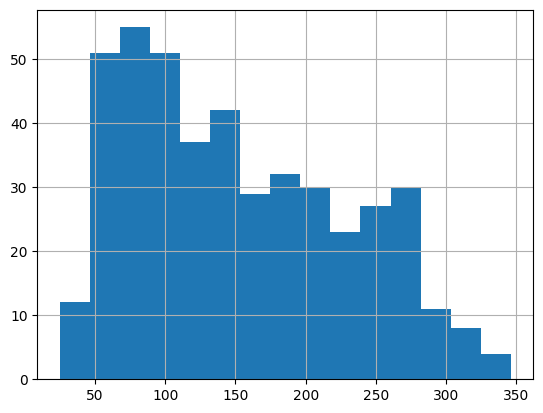

In [ ]:
# Plot histogram of the target variable (disease progression)
_ = df.target.hist(bins=15)

___
### *Observations from the Histogram*


*   Distribution Shape: Right-Skewed
*  The data has a "long tail" stretching toward the right (higher values).
Most patients have lower disease progression scores, with the highest concentration (the mode) falling between roughly 50 and 100.


*   As the progression score increases (above 200), the number of patients significantly drops off.
___



###  *Correlation of each feature with the target variable*

In [ ]:
# Compute the correlation matrix for all variables in the dataset
correlation_matrix = df.corr()

# Display the correlation of each feature with the target variable
correlation_matrix["target"]

,target
age,0.187889
sex,0.043062
bmi,0.586450
bp,0.441482
s1,0.212022
s2,0.174054
s3,-0.394789
s4,0.430453
s5,0.565883
s6,0.382483




---


### *Observations from Correlation Matrix*

### The "Heavy Hitters" (Strongest Positive Correlation)
These are your most important features. As Body Mass Index or the s5 serum measurement increases, the diabetes progression score tends to increase significantly.

### s3 (-0.395)
This is your only strong negative correlation. As the s3 value goes up, the target progression score tends to go down.

### The "Weak" Features (Low Correlation)
sex (0.043): This is very close to zero, indicating a weak relationship with the target.

---

# **4.Print the dimensions of the input data.**:

In [ ]:
print("Shape of input data:", diabetes.data.shape)

Shape of input data: (442, 10)




---


## Shape of Input Data

The input data has a shape of **(442, 10)**.

- **442** → the number of samples (patients) in the dataset.  
- **10** → the number of features (independent variables) measured for each patient, such as age, sex, BMI, blood pressure, and six blood serum measurements.

This indicates that the dataset contains **442 rows** (observations) and **10 columns** (features).


---




# **5.Split the data into a training and a test set.**

In [ ]:
X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42
)




---


## Choosing Test Size

The goal of splitting a dataset is to **maximize training data** while keeping enough for testing to evaluate generalization.  

- **Common rule of thumb:** 70–80% for training, 20–30% for testing.  
  - **70/30 split** is useful for smaller datasets when a more confident estimate of model performance is desired.  
- **Model considerations:**  
  - **K-Nearest Neighbors (KNN)** needs more training data to cover the feature space, since it is a lazy, instance-based learner.  
  - **Decision Trees** work well on small-to-medium datasets and do not require enormous training data.  

To balance these factors, the default **scikit-learn test size of 25%** is used.


---
## Interpretation of 25% Test Size

A **test size of 25%** means that **25% of the dataset is reserved for testing**, while the remaining **75% is used for training** the model.  

For the diabetes dataset with 442 samples:  

- **Training set:** 75% of 442 ≈ 331 samples  
- **Test set:** 25% of 442 ≈ 111 samples  

**`random_state=42`** is set to ensure that the **train-test split is reproducible**.  


---





# **6 & 8. Train , Evaluate and Discuss a K nearest neighbors model.**







---


### ***Note***

The diabetes dataset is considered a **"toy dataset"** in scikit-learn. It is intentionally curated, **clean**, and contains **no missing values or duplicate rows**.  

According to the official `load_diabetes` documentation, the dataset has a built-in parameter called `scaled`, which is **True by default**. The feature variables are **mean-centered** and scaled by the **standard deviation times the square root of the number of samples**.  Using the formula:

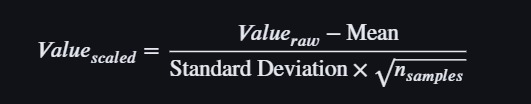


Scaling is important for KNN because it is a distance-based algorithm, and features on different scales can disproportionately influence the distance calculation.


### Conclusion:

Since the dataset is already cleaned and scaled, it is **ready for the training stage**, and the usual preprocessing steps have effectively been simplified.



---




### *Hyperparameter Considerations for KNN*

In [ ]:
# Initialize with defaults to see all available parameters
print(KNeighborsRegressor().get_params())

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}





---


When initializing a K-Nearest Neighbors (KNN) model with default settings, available parameters are:  

- **Algorithm & leaf_size:** These parameters affect the speed and efficiency of neighbor searches but do **not** change the final predictions. Unless computation is slow, they can be left at their default values.  
- **n_jobs:** Specifies the number of CPU cores to use. This is purely for computational efficiency and does not affect accuracy.  

The key hyperparameters that impact model performance are:  
- **K (number of neighbors)**  
- **Distance metric**  
- **Weighting function**  

By testing different combinations of these parameters, it is possible to identify the configuration that **minimizes error metrics** such as Mean Squared Error (MSE).


---






---

GridSearchCV was used to identify the optimal combination:

```python
parameters = {
    'n_neighbors': range(1, 51),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

gridsearch = GridSearchCV(
    KNeighborsRegressor(),
    parameters,
    scoring='neg_mean_squared_error'
)

gridsearch.fit(X_train, y_train)
```

### Observations

- The **distance metric** selected was equivalent to the default `'minkowski'` with `p=2` (same as **Euclidean distance**).  
- Initially, **weights = 'distance'** was chosen, but this caused severe overfitting, producing a **train RMSE close to 0** and **test RMSE of 54.62** .  
- Switching to **weights = 'uniform'** with **K = 17** yielded a better result, which is more realistic and demonstrates improved generalization.  

- This shows Using uniform weights with a moderate K balances bias and variance, reducing overfitting while maintaining predictive accuracy.


---




### **Build KNN Model by using GridSearchCV to get optimum n_neighbors**

In [ ]:
# Define a grid for the number of neighbors (1 to 50) to tune the KNN regressor
parameters_knn = {'n_neighbors': range(1, 51)}

# Perform Grid Search with cross-validation to find the optimal number of neighbors
gridsearch_knn = GridSearchCV(KNeighborsRegressor(), parameters_knn)

# Fit the GridSearchCV object on the training data
gridsearch_knn.fit(X_train, y_train)

GridSearchCV(estimator=KNeighborsRegressor(),
             param_grid={'n_neighbors': range(1, 51)})

In [ ]:
#print optimal parameters
gridsearch_knn.best_params_

{'n_neighbors': 17}

### *Predict on training data using the tuned KNN model*

In [ ]:
# Predict on training data using the tuned KNN model
pred_knn_train = gridsearch_knn.predict(X_train)

# Calculate training Mean Squared Error (MSE)
knn_train_mse = mean_squared_error(y_train, pred_knn_train)

# Convert MSE to Root Mean Squared Error (RMSE)
knn_train_rmse = np.sqrt(knn_train_mse)

# Display training RMSE
print(f"Train RMSE for KNN: {knn_train_rmse:.2f}")


Train RMSE for KNN: 55.63


### *Predict on test data using the tuned KNN model*

In [ ]:
# Predict on test data using the tuned KNN model
pred_knn_test = gridsearch_knn.predict(X_test)

# Calculate test Mean Squared Error (MSE)
knn_test_mse = mean_squared_error(y_test, pred_knn_test)

# Convert MSE to Root Mean Squared Error (RMSE)
knn_test_rmse = np.sqrt(knn_test_mse)

# Display test RMSE
print(f"Test RMSE for KNN:{knn_test_rmse:.2f}")

Test RMSE for KNN:54.62





---


### **Interpretation of KNN Model Performance**

The tuned K-Nearest Neighbors model produced:

- **Train RMSE:** 55.63  
- **Test RMSE:** 54.62  

### Interpretation

The training and test RMSE values are nearly identical, indicating that the model generalizes well and is not overfitting. The very small difference (≈1 unit) suggests strong stability and consistent predictive behavior across datasets.

The slightly lower test RMSE compared to the training RMSE may occur due to random variation in data splitting, where the test set happens to be marginally easier to predict. This difference is minor and does not indicate a significant modeling issue.

In the context of the diabetes dataset, an error of 54.62 means that, on average, the model's prediction of a patient's disease progression is off by about 54 points. reflects a moderate but respectable level of prediction error. The model captures meaningful patterns in the data, although predictions are not perfectly precise.


---



## KNN Regression Prediction Workflow (Example)

**Scenario:** Predict disease progression for a new patient using KNN, assuming this model:

- Features are already standardized  
- Optimal number of neighbors, **K = 17**  

---

### **Step 1: New patient arrives**

Example feature values (10 features from the diabetes dataset):

| Feature | Value |
|---------|-------|
| age     | 55    |
| sex     | 1     |
| bmi     | 28.5  |
| bp      | 80    |
| s1      | 200   |
| s2      | 100   |
| s3      | 50    |
| s4      | 3.8   |
| s5      | 1.2   |
| s6      | 85    |

---

### **Step 2: Compute distances**

- KNN calculates the **distance** from the new patient to **all training samples** using **Euclidean distance**:

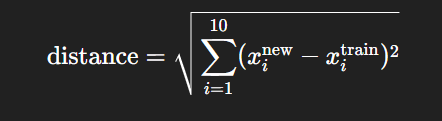
- **Standardization is critical** so that features with larger ranges do not dominate the distance calculation. Each feature contributes equally to similarity.

---

### **Step 3: Select nearest neighbors**

- The **17 closest training patients** are selected based on distance.  

---

### **Step 4: Aggregate target values**

- The predicted disease progression is the **average target value** of these 17 neighbors (`weights='uniform'`).  

---

### **Step 5: Output prediction**

- The model outputs a predicted value (e.g., ~152 units), representing the expected disease progression one year after baseline.  

---

### **Key Takeaways**

- KNN relies on **similarity to existing patients** to make predictions.  
- **Standardization ensures** that no feature dominates the distance metric.  
- KNN is a lazy learner: it does not build an explicit model during training; when test data arrives, it simply compares the new sample to existing training points to make predictions
___

## 7 & 8.Train and evaluate a decsion tree model

### ***Baseline Model***

In [ ]:
# Initialize the Decision Tree Regressor with a fixed random_state
dt_diabetes = DecisionTreeRegressor(random_state=42)

# Train (fit) the model on the training data
dt_diabetes.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

### *Baseline modelprediction on train data*

In [ ]:
# Predict on training data
baseline_pred_train = dt_diabetes.predict(X_train)

# Compute training MSE
mse_baseline_train = mean_squared_error(y_train, baseline_pred_train)

# Compute training RMSE
rmse_baseline_train = np.sqrt(mse_baseline_train)

# Display training RMSE
print(f"Baseline Train RMSE is:{rmse_baseline_train:.2f}")


Baseline Train RMSE is:0.00


### Baseline modelprediction on test data

In [ ]:
# Predict on test data
baseline_pred_test = dt_diabetes.predict(X_test)

# Compute test MSE
mse_baseline_test = mean_squared_error(y_test, baseline_pred_test)

# Compute test RMSE
rmse_baseline_test = np.sqrt(mse_baseline_test)

# Display test RMSE with message
print(f"Baseline Test RMSE is:, {rmse_baseline_test:.2f}")


Baseline Test RMSE is:, 77.08




---


The baseline Decision Tree model produced:

- **Train RMSE = 0.0**
- **Test RMSE = 77.08**

A training RMSE of 0.0 indicates that the model perfectly memorized the training data. However, the significantly higher test RMSE shows poor performance on unseen data. This is a clear sign of **overfitting**.

Therefore, **hyperparameter tuning is necessary** to control model complexity and improve generalization.


---




### *Hyperparameter Considerations for Decision Tree*

In [ ]:
# Print all hyperparameters (with their current values)
print(dt_diabetes.get_params())

{'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


___
After reviewing the default parameters using `get_params()`, only the hyperparameters that directly affect **model complexity and generalization** were selected for tuning. Parameters such as `criterion`, `splitter`, and similar settings were not tuned since they mainly influence implementation details rather than predictive accuracy.

### Focus on Pre-Pruning

Since decision trees tend to overfit (especially on small datasets), tuning focused on **pre-pruning parameters** that control tree growth:

- `max_depth` → limits tree depth (currently None is used.which allows the tree to grow indefinetly.)
- `min_samples_split` → controls when splits occur  
- `min_samples_leaf` → smooths predictions  

These parameters help balance bias and variance, improving generalization performance.
___

### ***Tuned Model using GridSearchCV***

In [ ]:
# Define grid of pre-pruning hyperparameters to control tree complexity
parameters_dt = {
    'max_depth': range(2, 11),
    'min_samples_split': range(2, 11),
    'min_samples_leaf': range(2, 11)
}

# Perform Grid Search with cross-validation to find best parameter combination
gridsearch_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    parameters_dt
)

# Fit grid search on training data
gridsearch_dt.fit(X_train, y_train)


GridSearchCV(estimator=DecisionTreeRegressor(random_state=42),
             param_grid={'max_depth': range(2, 11),
                         'min_samples_leaf': range(2, 11),
                         'min_samples_split': range(2, 11)})

In [ ]:
#optimum parameters
gridsearch_dt.best_params_

{'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 2}

### *Model Evalutation on train data*

In [ ]:
# Predict on training data using the tuned Decision Tree model
grid_dt_pred_train = gridsearch_dt.predict(X_train)

# Calculate training Mean Squared Error (MSE)
mse_grid_dt_train = mean_squared_error(y_train, grid_dt_pred_train)

# Convert MSE to Root Mean Squared Error (RMSE)
rmse_grid_dt_train = np.sqrt(mse_grid_dt_train)

# Display training RMSE after hyperparameter tuning
print(f"The Train RMSE after GridSearchCV:, {rmse_grid_dt_train:.2f}")


The Train RMSE after GridSearchCV:, 58.28


### *Model Evalutation on test data*

In [ ]:
# Predict on test data using the tuned Decision Tree model
grid_dt_pred_test = gridsearch_dt.predict(X_test)

# Calculate test Mean Squared Error (MSE)
mse_grid_dt_test = mean_squared_error(y_test, grid_dt_pred_test)

# Convert MSE to Root Mean Squared Error (RMSE)
rmse_grid_dt_test = np.sqrt(mse_grid_dt_test)

# Display test RMSE after hyperparameter tuning
print(f"The Test RMSE after GridSearchCV:, {rmse_grid_dt_test:.2f}")


The Test RMSE after GridSearchCV:, 59.55




---


### Observations After Evaluating the Tuned Decision Tree

- **Best Hyperparameters:** `{'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 2}`  
  *(Note: `min_samples_split=2` was also used in the baseline model)*

- **Train RMSE:** 58.28  
- **Test RMSE:** 59.55  

### Key Observations:

1. The training RMSE increased from 0.0 (baseline) to 58.28 after tuning, indicating that **overfitting has been greatly reduced**.  
2. The test RMSE (59.55) is now close to the training RMSE, showing that the model **generalizes much better** to unseen data.  
3. The small gap between train and test RMSE suggests a **good balance between bias and variance**.  
4. Using hyperparameter pre-pruning  effectively controlled tree complexity,  

**Conclusion:** Hyperparameter tuning successfully reduced overfitting and produced a model that generalizes well to the test set.


---




## Interpretation of Test RMSE

The **test RMSE of 59.55** represents the average magnitude of the prediction errors on the unseen test data.  

- Since the target variable in the diabetes dataset measures disease progression one year after baseline (values roughly from 25 to 346), an RMSE of 59.55 indicates that, on average, the model's predictions deviate from the true values by about **±60 units**.  
- Compared to the baseline model (test RMSE ~77), this shows a **improvement in generalization**.  
- The close alignment of train RMSE (58.28) and test RMSE (59.55) confirms that the model is **well-balanced** — not overfitting and capturing meaningful patterns from the data.


---



### **Visualizing the decision tree**

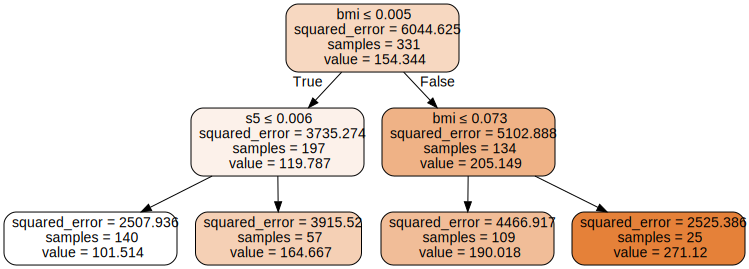

In [ ]:
# Export the tree to DOT format
dot_data = export_graphviz(
    gridsearch_dt.best_estimator_,
    out_file=None, #returns the DOT data as a string instead of saving a file
    feature_names=diabetes.feature_names,
    filled=True, #Colors the tree nodes according to the predicted target value
    rounded=True,
    special_characters=True
)

# Visualize the tree
graph = graphviz.Source(dot_data)
graph.view()
graph

##### ***Display of this graph requires installation of graphiz.To visualize on enviroments without graphiz,an additional screenshoot has been attached.***

![image.png](attachment:image.png)

### **Interpretation of the Tuned Decision Tree Visualization**

The Decision Tree Regressor uses **two levels of splits** to predict disease progression based on features  `bmi` and `s5`.

---

### 1. Root Node (Level 0)

- **Split Rule:** The first split is based on `bmi`. Patients below the threshold follow the left branch, while those above follow the right branch.  
- **Samples:** 331 data points are at the root.  
- **Value (154.344):** This is the average target value of all samples before splitting.  
- **Squared Error (6044.6):** Represents the total variance in the target at the root before any splitting occurred.It refers to the difference between one predicted value and its actual value squared, scikit-learn uses the label squared_error in its tree diagrams to represent the average of those values for all samples in that specific node

**Squared Error** is the default splitting criterion in decision tree regressor that tells the tree how to measure “goodness” of a split meaning the tree picks splits that minimize the variance (MSE) in the child nodes.

---

### 2. Level 1 Nodes ("Questions")

- **Left Branch (Low BMI):** The next split uses `s5` (a blood serum measure). Patients below the threshold are directed further left, predicting a lower target value.  
- **Right Branch (High BMI):** The split examines `bmi` again at a higher threshold. Patients above this threshold move to the far-right node, predicting the highest target values.

---

### 3. Leaf Nodes (Level 2 – Final Predictions)

The leaves represent the final predictions after two levels of splits. Predictions are the **mean target values of the samples in each leaf**:

| Leaf (Bucket) | Predicted Value | Samples
|---------------|----------------|---------
| Bucket 1 (Lowest Risk) | 101.514 | 140
| Bucket 2 | 164.667 | 57
| Bucket 3 | 190.018 | 109
| Bucket 4 (Highest Risk) | 271.12 | 25


---

### Summary

- The tree structure shows that **BMI and s5 are the most important features** in predicting disease progression.  
- Each patient follows a path from the root through the splits to a leaf, which determines the predicted target.  


## **8, Observations and conclusion after evaluating the models on the test set**

# Comparison of Models on the Test Set

| Aspect | Decision Tree Regressor | K-Nearest Neighbors (KNN) Regressor |
|--------|--------------------------|--------------------------------------|
| **How it Works** | Splits the data into regions using feature-based decision rules (if–then conditions). | Stores all training data and predicts by averaging the target values of the *K* closest neighbors. |
| **Learning Type** | Eager learner (builds a model during training). | Lazy learner (no explicit model; computation happens at prediction time). |
| **Need for Standardization** | Not required (tree-based). | Required (distance-based algorithm). |
| **Train RMSE** | 58.28 | 55.63 |
| **Test RMSE** | 59.55 | 54.62 |
| **Overfitting Check** | Train and test RMSE are close → good generalization | Train and test RMSE are very close →  stable |
| **Interpretability** | High (clear decision rules and splits). | Lower (predictions depend on neighbor distances). |
| **Prediction Behavior** | Produces step-like constant predictions per region. | Produces smoother predictions by averaging neighbors. |

---

## Observations

- Both models demonstrate good generalization, as indicated by the small difference between training and test RMSE values.  
- The KNN model achieves a lower **Test RMSE (54.62)** compared to the Decision Tree (**59.55**), indicating better predictive accuracy.  
- The Decision Tree is simpler and easier to interpret, but its shallow depth limits flexibility.  
- KNN benefits from standardization and optimal tuning of *K*, allowing it to capture local structure in the data more effectively.

---

## Conclusion

For this diabetes regression task, the **K-Nearest Neighbors Regressor** performs better in terms of predictive accuracy and stability on unseen data.  

Although the Decision Tree provides strong interpretability, the KNN model achieves lower error and better generalization. Therefore, based on test set performance, **KNN is the preferred model for this case.**